# Car Price Prediction with Machine Learning
**OIBSIP Data Science Track — Task 3**

Objective: predict the selling price of a used car from brand, age, mileage, fuel
type and transmission.

**Note on data:** built offline, so the real "Vehicle dataset from cardekho" could
not be downloaded from Kaggle. A synthetic dataset with the same columns and a
realistic pricing relationship (including messy values that need cleaning, as a real
scraped dataset would have) is generated below with a fixed seed. Swap in the real
CSV before submission — the cleaning/modelling code expects columns:
`car_name, year, selling_price, present_price, kms_driven, fuel_type, transmission`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
rng = np.random.default_rng(7)

n = 300
brands = ["Maruti", "Hyundai", "Honda", "Toyota", "Ford", "Tata", "Mahindra"]
brand_base_price = {"Maruti": 5, "Hyundai": 6, "Honda": 8, "Toyota": 12,
                     "Ford": 7, "Tata": 6, "Mahindra": 9}
fuel_types_raw = ["Petrol", "petrol", "Diesel", "diesel", "CNG"]
transmissions = ["Manual", "Automatic"]

rows = []
for i in range(n):
    brand = rng.choice(brands)
    year = int(rng.integers(2005, 2023))
    kms = max(500, int(rng.normal(45000, 25000)))
    fuel = rng.choice(fuel_types_raw, p=[0.35, 0.1, 0.3, 0.1, 0.15])
    trans = rng.choice(transmissions, p=[0.75, 0.25])
    age = 2024 - year
    present_price = brand_base_price[brand] + rng.normal(0, 1.0)
    present_price = max(2.5, present_price)
    depreciation = 0.08 * age + 0.000004 * kms
    fuel_adj = 0.3 if str(fuel).lower() == "diesel" else (-0.2 if str(fuel).lower() == "cng" else 0)
    trans_adj = 0.5 if trans == "Automatic" else 0
    selling_price = present_price * (1 - min(depreciation, 0.85)) + fuel_adj + trans_adj
    selling_price = round(max(0.5, selling_price + rng.normal(0, 0.4)), 2)
    car_name = f"{brand} Model{rng.integers(1,5)}"
    rows.append([car_name, year, selling_price, round(present_price, 2), kms, fuel, trans])

df = pd.DataFrame(rows, columns=["car_name", "year", "selling_price", "present_price",
                                  "kms_driven", "fuel_type", "transmission"])

# inject a few missing values and duplicate rows, like a real scraped dataset
na_idx = rng.choice(df.index, size=6, replace=False)
df.loc[na_idx, "present_price"] = np.nan
df = pd.concat([df, df.sample(4, random_state=1)], ignore_index=True)

print(df.head())
print("\nShape:", df.shape)

          car_name  year  selling_price  ...  kms_driven  fuel_type transmission
0  Mahindra Model4  2016           1.19  ...       52468     diesel       Manual
1    Maruti Model4  2013           1.15  ...       32694     Diesel       Manual
2  Mahindra Model2  2013           1.32  ...       44268     Diesel    Automatic
3  Mahindra Model1  2013           1.60  ...       39122     Diesel       Manual
4  Mahindra Model1  2013           1.23  ...       31532     Diesel       Manual

[5 rows x 7 columns]

Shape: (304, 7)


## 1. Data Cleaning

In [2]:
print("Nulls before cleaning:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nFuel type raw values:", df["fuel_type"].unique())

df = df.drop_duplicates().reset_index(drop=True)
df["fuel_type"] = df["fuel_type"].str.title()
df["present_price"] = df["present_price"].fillna(df["present_price"].median())

print("\nAfter cleaning — nulls:\n", df.isnull().sum())
print("Fuel type cleaned values:", df["fuel_type"].unique())
print("Shape after cleaning:", df.shape)

Nulls before cleaning:
 car_name         0
year             0
selling_price    0
present_price    6
kms_driven       0
fuel_type        0
transmission     0
dtype: int64

Duplicate rows: 4

Fuel type raw values: <StringArray>
['diesel', 'Diesel', 'petrol', 'CNG', 'Petrol']
Length: 5, dtype: str

After cleaning — nulls:
 car_name         0
year             0
selling_price    0
present_price    0
kms_driven       0
fuel_type        0
transmission     0
dtype: int64
Fuel type cleaned values: <StringArray>
['Diesel', 'Petrol', 'Cng']
Length: 3, dtype: str
Shape after cleaning: (300, 7)


## 2. Feature Engineering

In [3]:
df["car_age"] = 2024 - df["year"]
df["brand"] = df["car_name"].str.split().str[0]
print(df[["car_name", "brand", "year", "car_age"]].head())

          car_name     brand  year  car_age
0  Mahindra Model4  Mahindra  2016        8
1    Maruti Model4    Maruti  2013       11
2  Mahindra Model2  Mahindra  2013       11
3  Mahindra Model1  Mahindra  2013       11
4  Mahindra Model1  Mahindra  2013       11


## 3. Exploratory Data Analysis

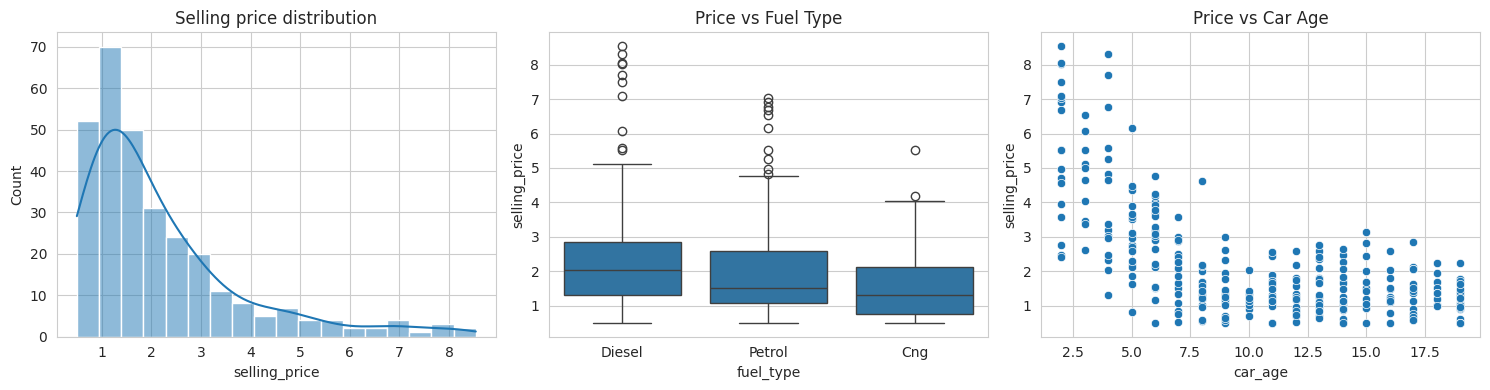

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df["selling_price"], kde=True, ax=axes[0])
axes[0].set_title("Selling price distribution")
sns.boxplot(data=df, x="fuel_type", y="selling_price", ax=axes[1])
axes[1].set_title("Price vs Fuel Type")
sns.scatterplot(data=df, x="car_age", y="selling_price", ax=axes[2])
axes[2].set_title("Price vs Car Age")
plt.tight_layout()
plt.show()

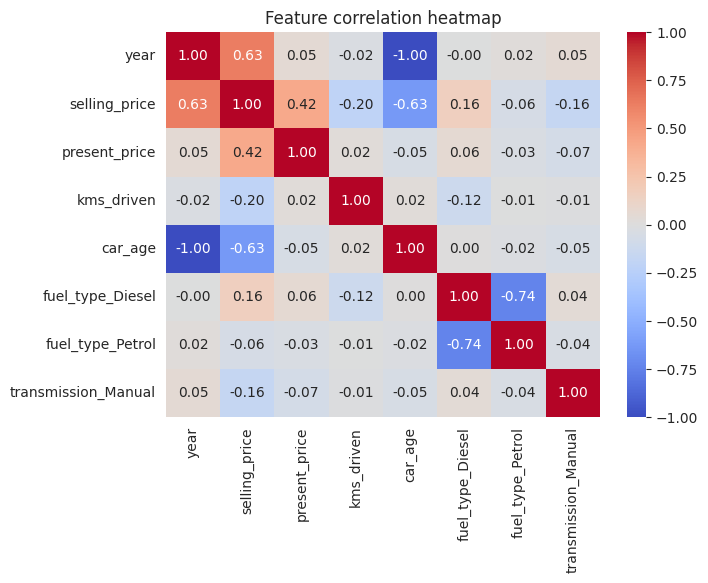

In [5]:
encoded = pd.get_dummies(df.drop(columns=["car_name", "brand"]), columns=["fuel_type", "transmission"], drop_first=True)
plt.figure(figsize=(7, 5))
sns.heatmap(encoded.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature correlation heatmap")
plt.show()

## 4. Modelling

In [6]:
X = encoded.drop(columns=["selling_price"])
y = encoded["selling_price"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lin = LinearRegression().fit(X_train, y_train)
rf = RandomForestRegressor(n_estimators=300, random_state=42).fit(X_train, y_train)

results = {}
for name, model in [("Linear Regression", lin), ("Random Forest", rf)]:
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = mean_squared_error(y_test, preds) ** 0.5
    r2 = r2_score(y_test, preds)
    results[name] = r2
    print(f"{name}: MAE={mae:.3f}  RMSE={rmse:.3f}  R2={r2:.3f}")

best_name = max(results, key=results.get)
print(f"\nBest model: {best_name}")

Linear Regression: MAE=0.819  RMSE=1.096  R2=0.666
Random Forest: MAE=0.441  RMSE=0.605  R2=0.898

Best model: Random Forest


car_age                0.404204
present_price          0.248892
year                   0.223378
kms_driven             0.082659
transmission_Manual    0.020383
fuel_type_Diesel       0.013591
fuel_type_Petrol       0.006893
dtype: float64


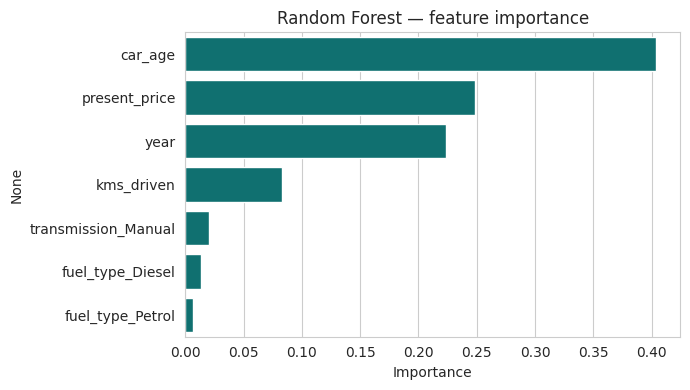

In [7]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(7, 4))
sns.barplot(x=importances.values, y=importances.index, color="teal")
plt.title("Random Forest — feature importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()
print(importances)

**Interpretation:** `present_price` (the car's original showroom price) and
`car_age` dominate the price prediction, which matches real-world used-car pricing
intuition — newer, higher-MSRP cars retain more value.